<a href="https://colab.research.google.com/github/kelly-u/AnaliseCafeEstresseQualidadeSono/blob/main/df_coffee.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = '/content/drive/MyDrive/GOOGLE COLAB/synthetic_coffee_health_10000.csv'
df_coffee = pd.read_csv(file_path)
display(df_coffee.head())

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


In [ ]:
df_coffee.describe()

,ID,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours,BMI,Heart_Rate,Physical_Activity_Hours,Smoking,Alcohol_Consumption
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000
mean,5000.50000,34.949100,2.509230,238.411010,6.636220,23.986860,70.617800,7.48704,0.20040,0.300700
std,2886.89568,11.160939,1.450248,137.748815,1.222055,3.906411,9.822951,4.31518,0.40032,0.458585
min,1.00000,18.000000,0.000000,0.000000,3.000000,15.000000,50.000000,0.00000,0.00000,0.000000
25%,2500.75000,26.000000,1.500000,138.750000,5.800000,21.300000,64.000000,3.70000,0.00000,0.000000
50%,5000.50000,34.000000,2.500000,235.400000,6.600000,24.000000,71.000000,7.50000,0.00000,0.000000
75%,7500.25000,43.000000,3.500000,332.025000,7.500000,26.600000,77.000000,11.20000,0.00000,1.000000
max,10000.00000,80.000000,8.200000,780.300000,10.000000,38.200000,109.000000,15.00000,1.00000,1.000000


In [ ]:
df_coffee.duplicated().sum() ##Verificamos se há dados duplicados

np.int64(0)

In [ ]:
df_coffee.isnull().sum() ##Quantidade de valores nulos

,0
ID,0
Age,0
Gender,0
Country,0
Coffee_Intake,0
Caffeine_mg,0
Sleep_Hours,0
Sleep_Quality,0
BMI,0
Heart_Rate,0


In [ ]:
print(f"Quantidade de linhas: {df_coffee.shape[0]}")
print(f"Quantidade de colunas: {df_coffee.shape[1]}")

Quantidade de linhas: 10000
Quantidade de colunas: 16


In [ ]:
##Nome das colunas
df_coffee.columns

Index(['ID', 'Age', 'Gender', 'Country', 'Coffee_Intake', 'Caffeine_mg',
       'Sleep_Hours', 'Sleep_Quality', 'BMI', 'Heart_Rate', 'Stress_Level',
       'Physical_Activity_Hours', 'Health_Issues', 'Occupation', 'Smoking',
       'Alcohol_Consumption'],
      dtype='object')

In [ ]:
df_coffee.dtypes ##Conhecemos os tipos de dados

,0
ID,int64
Age,int64
Gender,object
Country,object
Coffee_Intake,float64
Caffeine_mg,float64
Sleep_Hours,float64
Sleep_Quality,object
BMI,float64
Heart_Rate,int64


In [ ]:
display(df_coffee['Health_Issues'].head(50))

,Health_Issues
0,NaN
1,NaN
2,Mild
3,Mild
4,Mild
5,NaN
6,Mild
7,Mild
8,NaN
9,Mild


Analisaremos o conjunto de dados para compreender a relação entre o consumo de café e os padrões de sono, e também exploramos como a ingestão de café potencialmente afeta as horas e a qualidade do sono. Procuraremos levar em conta quaisquer outras variáveis significativas. Trataremos os valores ausentes na coluna 'Health_Issues' e utilizaremos métodos estatísticos e visualizações para apresentar os resultados.

In [ ]:
##Calculamos a média global de horas de sono para melhor compreender a tendência do dataset
sleep_hours_media = df_coffee['Sleep_Hours'].mean()

display(f"Média Global de Horas De Sono: {sleep_hours_media:.2f} horas")

'Média Global de Horas De Sono: 6.64 horas'

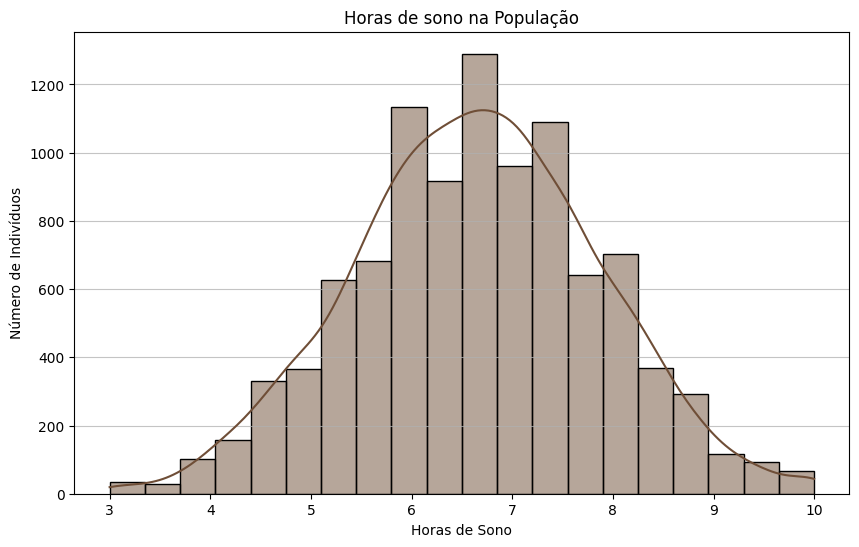

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_coffee['Sleep_Hours'], bins=20, kde=True, color='#6F4E37')
plt.title('Horas de sono na População')
plt.xlabel('Horas de Sono')
plt.ylabel('Número de Indivíduos')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Explorando a relação entre consumo de café e horas de sono

Procura-se compreender como as horas de sono se distribuem entre diferentes níveis de consumo de café e calcular a correlação entre a quantidade de café ingerida e as horas de sono.

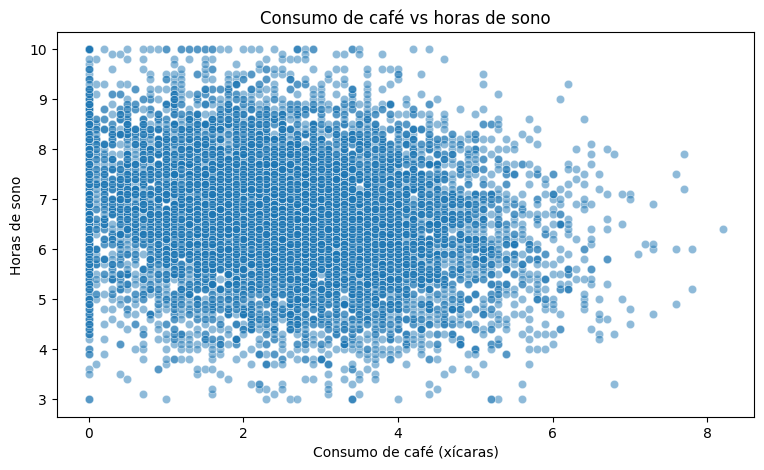

In [ ]:
##Categorizando Coffee_Intake em bins para facilitar análises futuras
bins = [0, 1, 2, 3, 4, 5, df_coffee['Coffee_Intake'].max()]
labels = ['0-1', '1-2', '2-3', '3-4', '4-5', '>5']
df_coffee['Coffee_Intake_Category'] = pd.cut(df_coffee['Coffee_Intake'], bins=bins, labels=labels, right=False)

##Gráfico de dispersão de Coffee_Intake e Sleep_Hours
plt.figure(figsize=(9, 5))
sns.scatterplot(x='Coffee_Intake', y='Sleep_Hours', data=df_coffee, alpha=0.5)
plt.title('Consumo de café vs horas de sono')
plt.xlabel('Consumo de café (xícaras)')
plt.ylabel('Horas de sono')
plt.show()

##Correlação entre o consumo de café e a quantidade de horas de sono
correlacao_cafe_sono = df_coffee['Coffee_Intake'].corr(df_coffee['Sleep_Hours'])


In [ ]:
from scipy.stats import chi2_contingency

##Adicionamos uma tabela para comparar os dados de qualidade do sono
tabela_cafe = pd.crosstab(df_coffee['Coffee_Intake_Category'], df_coffee['Sleep_Quality'])
display(tabela_cafe)


Sleep_Quality,Excellent,Fair,Good,Poor
Coffee_Intake_Category,,,,
0-1,316,231,902,83
1-2,356,387,1217,158
2-3,342,518,1521,237
3-4,213,485,1160,238
4-5,90,277,585,150
>5,35,152,251,95


##Possível influência de outras variáveis

É relevante explorar como outros fatores podem influenciar a relação entre o consumo de café e o sono.

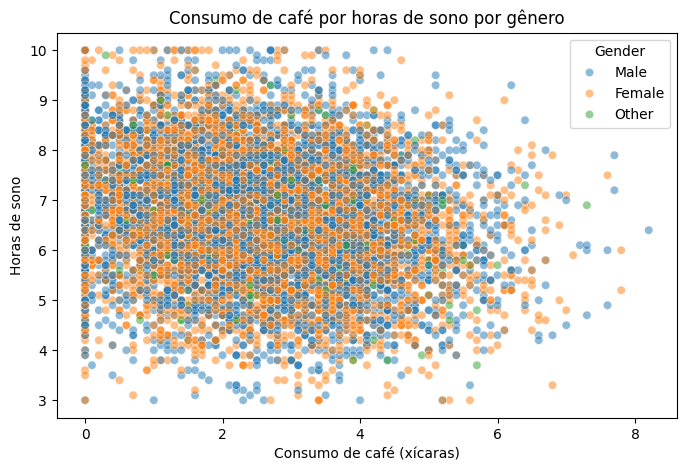

In [ ]:
##Analisando o consumo do café e as horas de sono para gêneros diferentes
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Coffee_Intake', y='Sleep_Hours', hue='Gender', data=df_coffee, alpha=0.5)
plt.title('Consumo de café por horas de sono por gênero')
plt.xlabel('Consumo de café (xícaras)')
plt.ylabel('Horas de sono')
plt.show()


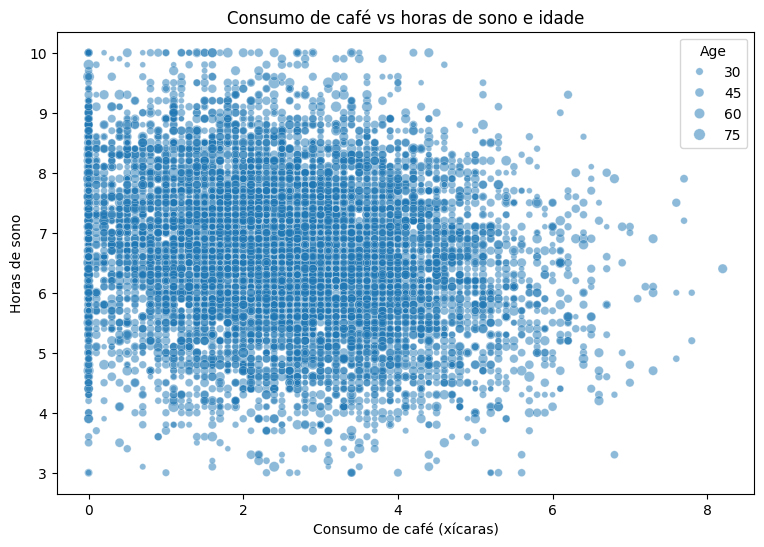

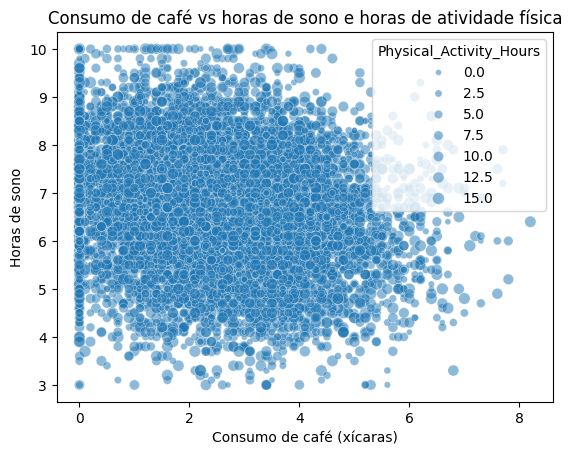

In [ ]:
##Consideramos uma possível correlação entre o consumo de café e as horas de sono considerando também a idade do indivíduo
plt.figure(figsize=(9, 6))
sns.scatterplot(x='Coffee_Intake', y='Sleep_Hours', size='Age', data=df_coffee, alpha=0.5)
plt.title('Consumo de café vs horas de sono e idade')
plt.xlabel('Consumo de café (xícaras)')
plt.ylabel('Horas de sono')
plt.show()

##E então também consideramos a relação entre o consumo de café e as horas de sono acoplados às horas de atividade física do indivíduo
sns.scatterplot(x='Coffee_Intake', y='Sleep_Hours', size='Physical_Activity_Hours', data=df_coffee, alpha=0.5)
plt.title('Consumo de café vs horas de sono e horas de atividade física')
plt.xlabel('Consumo de café (xícaras)')
plt.ylabel('Horas de sono')
plt.show()

Escolhemos, então, como lidar com os valores nulos na coluna Health_issues ("problemas de saúde")

É interessante checar a porcentagem de valores nulos na coluna para compreender melhor quanto isso pode afetar a análise.


In [ ]:
porcentagem_nulos_health_issues = (df_coffee['Health_Issues'].isnull().sum() / len(df_coffee)) * 100
print(f"Porcentagem de valores nulos em 'Health_Issues': {porcentagem_nulos_health_issues:.2f}%")

Porcentagem de valores nulos em 'Health_Issues': 59.41%


Como quase 60% dos dados da coluna Health_Issues estão faltando e essa variável é categórica, faz sentido preencher esses casos com uma categoria como “No Issues Reported” (“sem problemas relatados”). Dessa forma, não perdemos nenhuma linha do dataset e identificamos quem não informou nenhum problema de saúde.


In [ ]:
df_coffee['Health_Issues'] = df_coffee['Health_Issues'].fillna('No Issues Reported')
display(df_coffee['Health_Issues'].value_counts())

,count
Health_Issues,
No Issues Reported,5941
Mild,3579
Moderate,463
Severe,17


Com os dados substituídos, já podemos considerá-los na análise. Pensamos ser interessante explorar visualmente a influência desses dados. Abaixo, produzimos um gráfico de barras agrupadas, onde levamos em consideração a qualidade do sono, problemas de saúde e o consumo de café, e um diagrama de caixas de horas de sono vs nível de estresse tendo em vista que de todas as variáveis, esta parece ser mais influente.



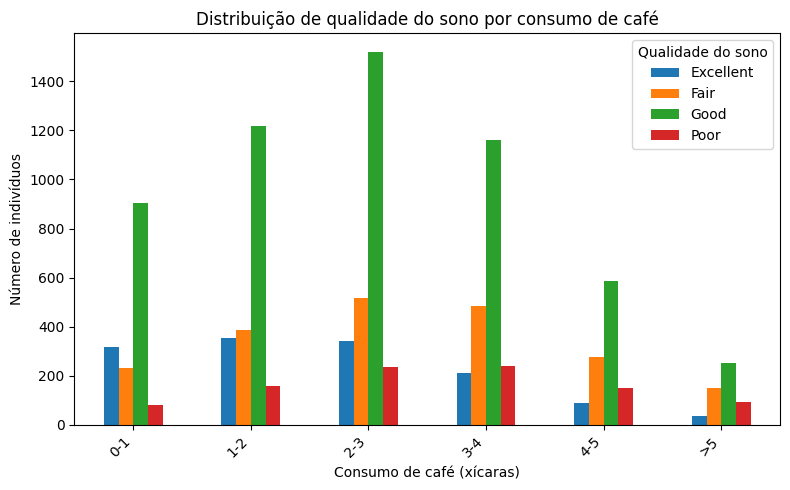

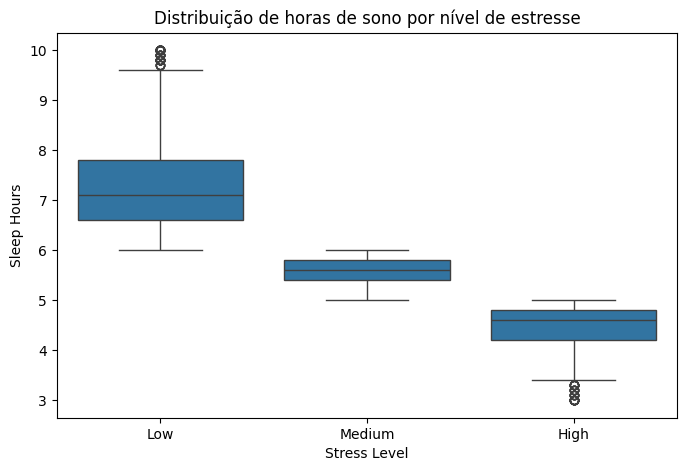

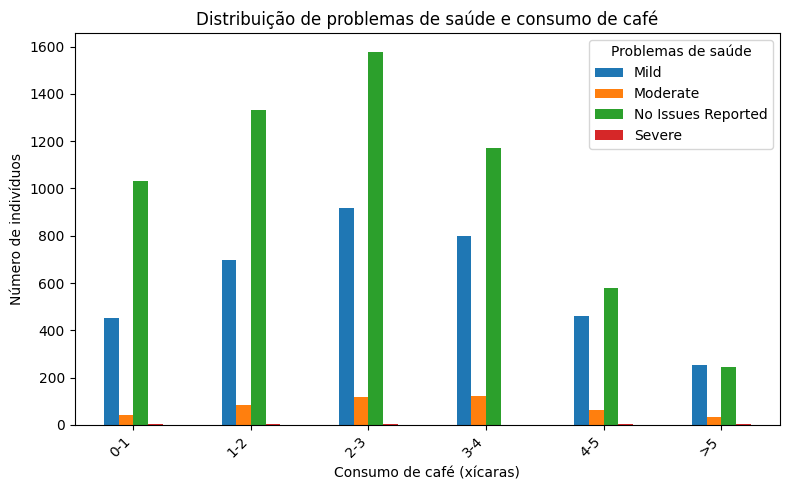

In [ ]:
##Adicionamos uma tabela para comparar os dados de qualidade do sono
contingency_table = pd.crosstab(df_coffee['Coffee_Intake_Category'], df_coffee['Sleep_Quality'])

##E então também adicionamos um gráfico de barras agrupado considerando a qualidade do sono e o consumo de café
contingency_table.plot(kind='bar', figsize=(8, 5))
plt.title('Distribuição de qualidade do sono por consumo de café')
plt.xlabel('Consumo de café (xícaras)')
plt.ylabel('Número de indivíduos')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Qualidade do sono')
plt.tight_layout()
plt.show()

##Adicionamos um diagrama de caixas comparando Sleep_Hours vs Stress_Level
plt.figure(figsize=(8, 5))
sns.boxplot(x='Stress_Level', y='Sleep_Hours', data=df_coffee)
plt.title('Distribuição de horas de sono por nível de estresse')
plt.xlabel('Stress Level')
plt.ylabel('Sleep Hours')
plt.show()

##Adicionamos mais uma tabela, comparando agora problemas de saúde vs consumo de café
tabela_saude = pd.crosstab(df_coffee['Coffee_Intake_Category'], df_coffee['Health_Issues'])

##E mais um gráfico de barras agrupadas para problemas de saúde vs consumo de café
tabela_saude.plot(kind='bar', figsize=(8, 5))
plt.title('Distribuição de problemas de saúde e consumo de café')
plt.xlabel('Consumo de café (xícaras)')
plt.ylabel('Número de indivíduos')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Problemas de saúde')
plt.tight_layout()
plt.show()

In [ ]:
##Calculamos a média de horas de sono para cada nível de estresse
media_sono_por_estresse = df_coffee.groupby('Stress_Level')['Sleep_Hours'].mean().reset_index()
print("Média de horas de sono por nível de estresse:")
display(media_sono_por_estresse)

##Calculamos a média de horas de sono para diferentes níveis de consumo de café
media_sono_consumo_cafe = df_coffee.groupby('Coffee_Intake_Category', observed=False)['Sleep_Hours'].mean().reset_index()
print("\nMédia de horas de sono por consumo de café:")
display(media_sono_consumo_cafe)

Média de horas de sono por nível de estresse:


,Stress_Level,Sleep_Hours
0,High,4.451925
1,Low,7.247332
2,Medium,5.576732



Média de horas de sono por consumo de café:


,Coffee_Intake_Category,Sleep_Hours
0,0-1,6.973564
1,1-2,6.815297
2,2-3,6.651872
3,3-4,6.462405
4,4-5,6.356624
5,>5,6.140150


####Percebemos que ainda mais claro seria se agrupássemos o nível de estresse e o consumo de café em uma só categoria e calculássemos a média de horas de sono.

In [ ]:
estresse_cafe_combinados = df_coffee.groupby(['Stress_Level', 'Coffee_Intake_Category'], observed=False)['Sleep_Hours'].mean().reset_index()
display(estresse_cafe_combinados)

,Stress_Level,Coffee_Intake_Category,Sleep_Hours
0,High,0-1,4.412048
1,High,1-2,4.448734
2,High,2-3,4.474262
3,High,3-4,4.434454
4,High,4-5,4.484667
5,High,>5,4.428421
6,Low,0-1,7.415517
7,Low,1-2,7.349777
8,Low,2-3,7.225980
9,Low,3-4,7.134013


###E então construímos a visualização desse agrupamento; vemos a média de horas de sono para cada combinação de nível de estresse e quantidade de café consumido.

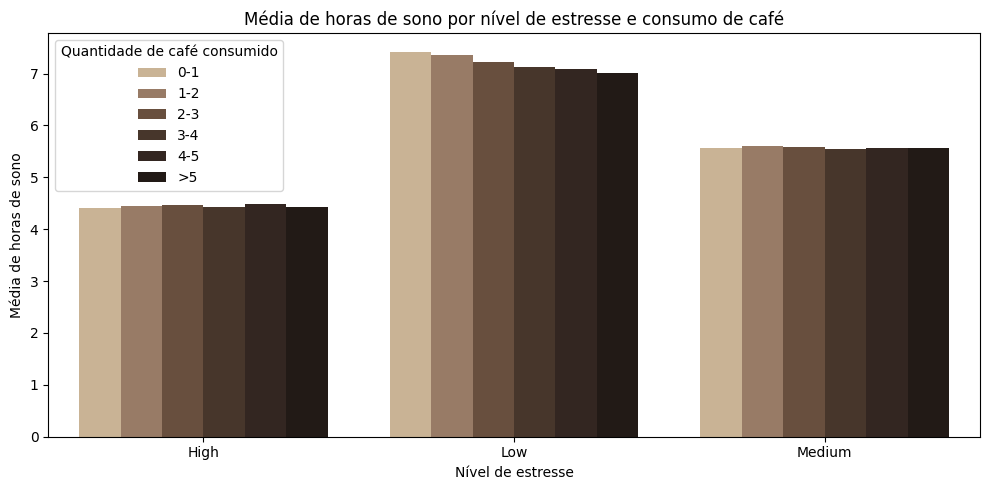

In [ ]:
paleta_cafe = [
    '#D2B48C',
    '#A07A5E',
    '#6F4E37',
    '#4C3526',
    '#36251E',
    '#241914'
]

num_coffee_categories = len(estresse_cafe_combinados['Coffee_Intake_Category'].unique())

plt.figure(figsize=(10, 5))
sns.barplot(x='Stress_Level', y='Sleep_Hours', hue='Coffee_Intake_Category', data=estresse_cafe_combinados, palette=selected_palette)

plt.title('Média de horas de sono por nível de estresse e consumo de café')

plt.xlabel('Nível de estresse')
plt.ylabel('Média de horas de sono')

plt.legend(title='Quantidade de café consumido')

plt.tight_layout()

plt.show()

Diante do conhecimento comum de que a quantidade de café que um indivíduo bebe tem relação com quantas horas ela dorme, analisamos as possibilidades; os dados mostram uma pequena tendência, que indica que quem bebe mais café, em média, dorme um pouco menos. O café indica ter certa influência, mas não é o único fator, e a relação não é muito expressiva. É relevante apontar que mesmo considerando a idade e quanto exercício físico está presente na vida do sujeito, ainda se faz presente uma pequena relação entre mais consumo de café e menos horas de sono.

Investigamos se o nível de estresse afeta quantas horas as pessoas dormem. Aqui, a relação é muito mais clara e forte; indivíduos com níveis mais altos de estresse dormem significativamente menos horas do que indivíduos com pouco ou médio estresse. Este impacto negativo do estresse no sono aparenta ser independente da quantidade de café consumida. Para indivíduos com estresse baixo ou médio, faz-se presente uma sutil diminuição na média de horas dormidas a medida que o consumo de café aumenta, mas esse efeito é menos pronunciado que o efeito causado pelo estresse.


Analisamos se homens e mulheres dormem uma quantidade de horas diferente, e não encontramos uma diferença significativa nas horas de sono entre homens e mulheres.


A análise indica que intervenções voltadas ao gerenciamento do estresse são mais eficazes para melhorar o sono do que estratégias centradas exclusivamente na diminuição da cafeína. Estudos posteriores podem incluir variáveis adicionais, como hábitos alimentares e tempo de tela, para compreender melhor sua influência e interação com o estresse e o consumo de café.
